# Pothole Segmentation Final Notebook

This notebook trains a classical machine learning model for pothole segmentation using ARA 7.0 as the main image and mask dataset, plus RDD2022 India as external negative only data.

Main objective:

1. Improve false positive behavior on shadows, wet roads, and smooth asphalt.
2. Keep validation fair by evaluating only on ARA validation masks.
3. Build two deployment artifacts: a fast LightGBM model for real-time Streamlit and an optional accuracy model using soft ensemble.
4. Generate submission.csv, metrics files, and a ready to run app.py.

This notebook uses classical machine learning only. No deep learning is used.


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import gc
import json
import time
import math
import random
import warnings
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from dataclasses import dataclass, asdict

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from skimage.feature import local_binary_pattern

warnings.filterwarnings("ignore")

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print("LightGBM is not available")
    print(e)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost is not available")
    print(e)

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception as e:
    HAS_CAT = False
    print("CatBoost is not available")
    print(e)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Training size. 320 is a good balance between mask quality and runtime.
WORK_SIZE = 320
APP_WORK_SIZE = 256
VAL_SIZE = 0.20

# ARA sampling. Positive and negative pixels are balanced to fight class imbalance.
PIXELS_PER_ARA_IMAGE = 2600
POS_FRACTION = 0.50
HARD_NEG_FRACTION = 0.70

# RDD2022 India is used as negative only data.
# This helps the model learn that smooth asphalt, shadows, and wet looking road are not always potholes.
USE_RDD_INDIA_NEGATIVES = True
MAX_RDD_IMAGES = 700
RDD_NEG_PIXELS_PER_IMAGE = 900
RDD_EXCLUDE_POTHOLE_BBOX = True

# Models. ExtraTrees is disabled because it is slow for pixel level segmentation.
RUN_LGBM = True
RUN_XGB = True
RUN_CAT = True
RUN_SOFT_ENSEMBLE = True

CAT_TRAIN_LIMIT = 320000
XGB_TRAIN_LIMIT = 650000

OUTPUT_DIR = Path("/kaggle/working/pothole_output") if Path("/kaggle/working").exists() else Path("./pothole_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RLE_ORDER = "F"

print("HAS_LGBM:", HAS_LGBM)
print("HAS_XGB:", HAS_XGB)
print("HAS_CAT:", HAS_CAT)
print("OUTPUT_DIR:", OUTPUT_DIR)


HAS_LGBM: True
HAS_XGB: True
HAS_CAT: True
OUTPUT_DIR: /kaggle/working/pothole_output


In [2]:
# ============================================================
# 2. Dataset discovery
# ============================================================

def find_ara_root():
    roots = []
    search_roots = [Path("/kaggle/input/competitions/data-science-ara-7-0"), Path("."), Path("/mnt/data")]
    for base in search_roots:
        if not base.exists():
            continue
        for p in [base] + list(base.rglob("*")):
            if not p.is_dir():
                continue
            if (p / "train" / "images").exists() and (p / "train" / "mask").exists() and (p / "test" / "images").exists():
                roots.append(p)
    if not roots:
        raise FileNotFoundError("ARA dataset root not found. Expected train/images, train/mask, test/images.")
    roots = sorted(roots, key=lambda x: len(str(x)))
    return roots[0]


def prepare_rdd_india_root():
    if not USE_RDD_INDIA_NEGATIVES:
        return None

    bases = [Path("/kaggle/input/datasets/fadhlannurrachman/rdd2022-india"), Path("."), Path("/mnt/data")]

    # If extracted already, prefer extracted folder.
    for base in bases:
        if not base.exists():
            continue
        for p in [base] + list(base.rglob("*")):
            if not p.is_dir():
                continue
            name = p.name.lower()
            if "india" in name or "rdd" in name:
                has_img = any(x.suffix.lower() in [".jpg", ".jpeg", ".png"] for x in p.rglob("*"))
                has_xml = any(x.suffix.lower() == ".xml" for x in p.rglob("*"))
                if has_img:
                    print("RDD extracted candidate:", p)
                    return p

    # If zip exists, extract to working directory.
    zip_candidates = []
    for base in bases:
        if not base.exists():
            continue
        zip_candidates.extend(list(base.rglob("*India*.zip")))
        zip_candidates.extend(list(base.rglob("*RDD2022*.zip")))
        zip_candidates.extend(list(base.rglob("*rdd*.zip")))

    zip_candidates = sorted(set(zip_candidates), key=lambda x: len(str(x)))
    if not zip_candidates:
        print("RDD India zip not found. Training will continue with ARA only.")
        return None

    zpath = zip_candidates[0]
    extract_dir = Path("/kaggle/working/rdd_india_extracted") if Path("/kaggle/working").exists() else Path("./rdd_india_extracted")
    marker = extract_dir / ".extracted"
    if not marker.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        print("Extracting RDD zip:", zpath)
        with zipfile.ZipFile(zpath, "r") as zf:
            zf.extractall(extract_dir)
        marker.write_text("done")
    else:
        print("RDD already extracted:", extract_dir)
    return extract_dir


def extract_id_from_name(path):
    stem = Path(path).stem
    digits = "".join([c for c in stem if c.isdigit()])
    return digits if digits else stem


ARA_ROOT = find_ara_root()
RDD_ROOT = prepare_rdd_india_root()

TRAIN_IMG_DIR = ARA_ROOT / "train" / "images"
TRAIN_MASK_DIR = ARA_ROOT / "train" / "mask"
TEST_IMG_DIR = ARA_ROOT / "test" / "images"

sample_paths = list(ARA_ROOT.glob("sample_submission.csv")) + list(ARA_ROOT.parent.glob("sample_submission.csv"))
SAMPLE_SUB_PATH = sample_paths[0] if sample_paths else None

print("ARA_ROOT:", ARA_ROOT)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TRAIN_MASK_DIR:", TRAIN_MASK_DIR)
print("TEST_IMG_DIR:", TEST_IMG_DIR)
print("SAMPLE_SUB_PATH:", SAMPLE_SUB_PATH)
print("RDD_ROOT:", RDD_ROOT)


RDD extracted candidate: /kaggle/input/datasets/fadhlannurrachman/rdd2022-india
ARA_ROOT: /kaggle/input/competitions/data-science-ara-7-0/dataset/dataset
TRAIN_IMG_DIR: /kaggle/input/competitions/data-science-ara-7-0/dataset/dataset/train/images
TRAIN_MASK_DIR: /kaggle/input/competitions/data-science-ara-7-0/dataset/dataset/train/mask
TEST_IMG_DIR: /kaggle/input/competitions/data-science-ara-7-0/dataset/dataset/test/images
SAMPLE_SUB_PATH: None
RDD_ROOT: /kaggle/input/datasets/fadhlannurrachman/rdd2022-india


In [3]:
# ============================================================
# 3. Dataframe builders and basic reading functions
# ============================================================

def read_bgr(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    return img


def read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Cannot read mask: {path}")
    return (mask > 127).astype(np.uint8)


def build_ara_train_dataframe():
    image_paths = sorted(list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.png")) + list(TRAIN_IMG_DIR.glob("*.jpeg")))
    mask_paths = sorted(list(TRAIN_MASK_DIR.glob("*.png")) + list(TRAIN_MASK_DIR.glob("*.jpg")) + list(TRAIN_MASK_DIR.glob("*.jpeg")))
    mask_map = {extract_id_from_name(p): p for p in mask_paths}
    rows = []
    missing = []
    for img_path in image_paths:
        sid = extract_id_from_name(img_path)
        mask_path = mask_map.get(sid)
        if mask_path is None:
            missing.append(img_path.name)
            continue
        rows.append({
            "id": sid,
            "image_path": str(img_path),
            "mask_path": str(mask_path),
            "image_name": img_path.name,
            "mask_name": mask_path.name,
            "source": "ara",
        })
    if missing:
        print("Images without mask:", len(missing), missing[:5])
    return pd.DataFrame(rows)


def build_ara_test_dataframe():
    image_paths = sorted(list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.png")) + list(TEST_IMG_DIR.glob("*.jpeg")))
    df = pd.DataFrame({
        "image_path": [str(p) for p in image_paths],
        "ImageId": [p.name for p in image_paths],
        "id": [extract_id_from_name(p) for p in image_paths],
    })
    if SAMPLE_SUB_PATH is not None:
        sample = pd.read_csv(SAMPLE_SUB_PATH)
        if "ImageId" in sample.columns:
            order = {name: i for i, name in enumerate(sample["ImageId"].astype(str).tolist())}
            df["order"] = df["ImageId"].map(order).fillna(10**9).astype(int)
            df = df.sort_values(["order", "ImageId"]).drop(columns=["order"]).reset_index(drop=True)
    return df


ara_df = build_ara_train_dataframe()
test_df = build_ara_test_dataframe()

print("ARA train pairs:", len(ara_df))
print("ARA test images:", len(test_df))
display(ara_df.head())
display(test_df.head())


ARA train pairs: 498
ARA test images: 295


,id,image_path,mask_path,image_name,mask_name,source
0,001,/kaggle/input/competitions/data-science-ara-7-...,/kaggle/input/competitions/data-science-ara-7-...,train_001.jpg,mask_001.png,ara
1,002,/kaggle/input/competitions/data-science-ara-7-...,/kaggle/input/competitions/data-science-ara-7-...,train_002.jpg,mask_002.png,ara
2,003,/kaggle/input/competitions/data-science-ara-7-...,/kaggle/input/competitions/data-science-ara-7-...,train_003.jpg,mask_003.png,ara
3,004,/kaggle/input/competitions/data-science-ara-7-...,/kaggle/input/competitions/data-science-ara-7-...,train_004.jpg,mask_004.png,ara
4,005,/kaggle/input/competitions/data-science-ara-7-...,/kaggle/input/competitions/data-science-ara-7-...,train_005.jpg,mask_005.png,ara


,image_path,ImageId,id
0,/kaggle/input/competitions/data-science-ara-7-...,test_001.jpg,001
1,/kaggle/input/competitions/data-science-ara-7-...,test_002.jpg,002
2,/kaggle/input/competitions/data-science-ara-7-...,test_003.jpg,003
3,/kaggle/input/competitions/data-science-ara-7-...,test_004.jpg,004
4,/kaggle/input/competitions/data-science-ara-7-...,test_005.jpg,005


In [4]:
# ============================================================
# 4. RDD2022 India negative only loader
# ============================================================

POTHOLE_LABELS = {"d40", "pothole", "pot hole", "potholes"}


def parse_voc_boxes(xml_path):
    boxes = []
    try:
        root = ET.parse(str(xml_path)).getroot()
    except Exception:
        return boxes
    for obj in root.findall("object"):
        name_node = obj.find("name")
        label = name_node.text.strip().lower() if name_node is not None and name_node.text is not None else ""
        bb = obj.find("bndbox")
        if bb is None:
            continue
        try:
            xmin = int(float(bb.find("xmin").text))
            ymin = int(float(bb.find("ymin").text))
            xmax = int(float(bb.find("xmax").text))
            ymax = int(float(bb.find("ymax").text))
        except Exception:
            continue
        boxes.append({"label": label, "bbox": [xmin, ymin, xmax, ymax]})
    return boxes


def build_rdd_dataframe(rdd_root):
    if rdd_root is None or not Path(rdd_root).exists():
        return pd.DataFrame(columns=["image_path", "xml_path", "image_name", "has_pothole_bbox", "source"])

    rdd_root = Path(rdd_root)
    image_paths = sorted([p for p in rdd_root.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    xml_paths = sorted([p for p in rdd_root.rglob("*.xml")])
    xml_map = {p.stem: p for p in xml_paths}

    rows = []
    for img_path in image_paths:
        # skip non road preview files if any
        if img_path.name.startswith("._"):
            continue
        xml_path = xml_map.get(img_path.stem)
        boxes = parse_voc_boxes(xml_path) if xml_path is not None else []
        has_pothole = any(b["label"] in POTHOLE_LABELS or b["label"] == "d40" for b in boxes)
        rows.append({
            "image_path": str(img_path),
            "xml_path": str(xml_path) if xml_path is not None else "",
            "image_name": img_path.name,
            "has_pothole_bbox": bool(has_pothole),
            "source": "rdd_india_negative",
        })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        # Prefer images without pothole bbox, then sample a limited amount for runtime.
        df = df.sort_values(["has_pothole_bbox", "image_name"]).reset_index(drop=True)
        df = df.head(MAX_RDD_IMAGES).copy()
    return df


rdd_df = build_rdd_dataframe(RDD_ROOT)
print("RDD negative candidate images:", len(rdd_df))
if len(rdd_df) > 0:
    print(rdd_df["has_pothole_bbox"].value_counts())
    display(rdd_df.head())


RDD negative candidate images: 700
has_pothole_bbox
False    700
Name: count, dtype: int64


,image_path,xml_path,image_name,has_pothole_bbox,source
0,/kaggle/input/datasets/fadhlannurrachman/rdd20...,/kaggle/input/datasets/fadhlannurrachman/rdd20...,India_000000.jpg,False,rdd_india_negative
1,/kaggle/input/datasets/fadhlannurrachman/rdd20...,/kaggle/input/datasets/fadhlannurrachman/rdd20...,India_000001.jpg,False,rdd_india_negative
2,/kaggle/input/datasets/fadhlannurrachman/rdd20...,/kaggle/input/datasets/fadhlannurrachman/rdd20...,India_000002.jpg,False,rdd_india_negative
3,/kaggle/input/datasets/fadhlannurrachman/rdd20...,/kaggle/input/datasets/fadhlannurrachman/rdd20...,India_000003.jpg,False,rdd_india_negative
4,/kaggle/input/datasets/fadhlannurrachman/rdd20...,,India_000004.jpg,False,rdd_india_negative


In [10]:
# ============================================================
# 5. ARA dataset audit and split
# ============================================================

ratios = []
shapes = []
for _, row in ara_df.iterrows():
    img = read_bgr(row["image_path"])
    m = read_mask(row["mask_path"])
    ratios.append(float(m.mean()))
    shapes.append(img.shape[:2])

ara_df["mask_ratio"] = ratios
ara_df["height"] = [s[0] for s in shapes]
ara_df["width"] = [s[1] for s in shapes]

print(ara_df[["mask_ratio", "height", "width"]].describe())
ara_df.to_csv(OUTPUT_DIR / "dataset_audit.csv", index=False)

bins = pd.cut(
    ara_df["mask_ratio"],
    bins=[-0.001, 0.001, 0.01, 0.03, 0.08, 0.18, 1.0],
    labels=False,
    include_lowest=True,
)
stratify = bins if bins.nunique() > 1 and bins.value_counts().min() >= 2 else None

train_df, val_df = train_test_split(
    ara_df,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train ARA images:", len(train_df))
print("Validation ARA images:", len(val_df))
print("Train mean mask ratio:", train_df["mask_ratio"].mean())
print("Validation mean mask ratio:", val_df["mask_ratio"].mean())
print("Mask ratio gap:", abs(train_df["mask_ratio"].mean() - val_df["mask_ratio"].mean()))


       mask_ratio       height        width
count  498.000000   498.000000   498.000000
mean     0.134860  1149.765060  1215.540161
std      0.128772  1350.057906  1150.368022
min      0.000235   129.000000   200.000000
25%      0.040943   300.000000   416.000000
50%      0.091678   525.000000   720.000000
75%      0.193834   857.000000  1278.000000
max      0.674005  4608.000000  4080.000000
Train ARA images: 398
Validation ARA images: 100
Train mean mask ratio: 0.1369499669113671
Validation mean mask ratio: 0.1265419102822996
Mask ratio gap: 0.010408056629067491


In [11]:
# ============================================================
# 6. Feature engineering
# ============================================================

def normalize01(x):
    x = x.astype(np.float32)
    mn = float(np.nanmin(x))
    mx = float(np.nanmax(x))
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mn) / (mx - mn + 1e-8)).astype(np.float32)


def local_mean_std(gray, k=7):
    gray = gray.astype(np.float32)
    mean = cv2.blur(gray, (k, k))
    mean_sq = cv2.blur(gray * gray, (k, k))
    var = np.maximum(mean_sq - mean * mean, 0)
    std = np.sqrt(var)
    return mean.astype(np.float32), normalize01(std)


def conservative_road_mask(bgr):
    h, w = bgr.shape[:2]
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    sky = np.zeros((h, w), dtype=np.uint8)
    top_h = max(1, h // 2)
    sky_region = ((H[:top_h] >= 85) & (H[:top_h] <= 140) & (S[:top_h] <= 135) & (V[:top_h] >= 80))
    sky[:top_h][sky_region] = 1

    g = bgr[:, :, 1].astype(np.int16)
    r = bgr[:, :, 2].astype(np.int16)
    veg = ((H >= 25) & (H <= 95) & (S >= 35) & (g > r + 5)).astype(np.uint8)

    road = (1 - np.clip(sky + veg, 0, 1)).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    road = cv2.morphologyEx(road * 255, cv2.MORPH_CLOSE, k, iterations=2)
    road = cv2.morphologyEx(road, cv2.MORPH_OPEN, k, iterations=1)
    road = (road > 0).astype(np.uint8)

    n, labels, stats, cent = cv2.connectedComponentsWithStats(road, 8)
    if n <= 1:
        fallback = np.zeros((h, w), dtype=np.uint8)
        fallback[h // 3:] = 1
        return fallback

    best = 1
    best_score = -1
    for lab in range(1, n):
        area = stats[lab, cv2.CC_STAT_AREA]
        cy = cent[lab][1]
        score = area * (0.4 + cy / max(h, 1))
        if score > best_score:
            best_score = score
            best = lab
    road = (labels == best).astype(np.uint8)
    road[: int(h * 0.06)] = 0
    return road


def build_gabor_kernels():
    kernels = []
    for theta in [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]:
        kernels.append(cv2.getGaborKernel((15, 15), 3.0, theta, 8.0, 0.5, 0, ktype=cv2.CV_32F))
    return kernels


GABOR_KERNELS = build_gabor_kernels()


def build_feature_map(bgr):
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    H = hsv[:, :, 0] / 179.0
    S = hsv[:, :, 1] / 255.0
    V = hsv[:, :, 2] / 255.0
    L = lab[:, :, 0] / 255.0
    A = lab[:, :, 1] / 255.0
    B = lab[:, :, 2] / 255.0

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    gray_u8 = (gray * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray_u8).astype(np.float32) / 255.0
    illum = cv2.GaussianBlur(gray, (0, 0), sigmaX=25)
    illum_norm = normalize01(gray / (illum + 1e-4))

    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = normalize01(np.sqrt(sx * sx + sy * sy))
    grad_ang = (np.arctan2(sy, sx) + np.pi) / (2 * np.pi)
    lap = normalize01(np.abs(cv2.Laplacian(gray, cv2.CV_32F, ksize=3)))

    mean7, std7 = local_mean_std(gray, 7)
    mean15, std15 = local_mean_std(gray, 15)

    blackhat_feats = []
    for ksize in [15, 31, 61]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        bh = cv2.morphologyEx(gray_u8, cv2.MORPH_BLACKHAT, kernel).astype(np.float32)
        blackhat_feats.append(normalize01(bh))

    lbp = local_binary_pattern(gray_u8, P=8, R=1, method="uniform").astype(np.float32)
    lbp = lbp / (lbp.max() + 1e-8)

    gabor_feats = []
    for kern in GABOR_KERNELS:
        resp = cv2.filter2D(gray, cv2.CV_32F, kern)
        gabor_feats.append(normalize01(np.abs(resp)))

    ys, xs = np.mgrid[0:h, 0:w]
    x_norm = xs.astype(np.float32) / max(w - 1, 1)
    y_norm = ys.astype(np.float32) / max(h - 1, 1)
    bottom_prior = y_norm ** 2
    center_x = np.abs(x_norm - 0.5)

    road = conservative_road_mask(bgr).astype(np.float32)

    low_sat = 1.0 - S
    dark = 1.0 - V
    wet_like = normalize01(low_sat * (0.5 * V + 0.5 * (1.0 - std15)))
    shadow_like = normalize01(dark * low_sat * (1.0 - grad_mag))
    dark_edge = normalize01(dark * grad_mag)
    specular_like = normalize01((V > 0.75).astype(np.float32) * low_sat * (1.0 - S))

    maps = [
        rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2],
        H, S, V,
        L, A, B,
        gray, clahe, illum_norm,
        grad_mag, grad_ang, lap,
        mean7, std7, mean15, std15,
        lbp,
        x_norm, y_norm, bottom_prior, center_x,
        road,
        wet_like, shadow_like, dark_edge, specular_like,
    ]
    maps.extend(blackhat_feats)
    maps.extend(gabor_feats)
    feat = np.stack(maps, axis=-1).astype(np.float32)
    return feat


FEATURE_NAMES = [
    "R", "G", "B",
    "HSV_H", "HSV_S", "HSV_V",
    "LAB_L", "LAB_A", "LAB_B",
    "gray", "clahe", "illum_norm",
    "grad_mag", "grad_ang", "laplacian",
    "mean7", "std7", "mean15", "std15",
    "lbp",
    "x_norm", "y_norm", "bottom_prior", "center_x",
    "road_mask",
    "wet_like", "shadow_like", "dark_edge", "specular_like",
    "blackhat15", "blackhat31", "blackhat61",
] + [f"gabor_{i}" for i in range(len(GABOR_KERNELS))]

print("Number of features:", len(FEATURE_NAMES))
print(FEATURE_NAMES)


Number of features: 36
['R', 'G', 'B', 'HSV_H', 'HSV_S', 'HSV_V', 'LAB_L', 'LAB_A', 'LAB_B', 'gray', 'clahe', 'illum_norm', 'grad_mag', 'grad_ang', 'laplacian', 'mean7', 'std7', 'mean15', 'std15', 'lbp', 'x_norm', 'y_norm', 'bottom_prior', 'center_x', 'road_mask', 'wet_like', 'shadow_like', 'dark_edge', 'specular_like', 'blackhat15', 'blackhat31', 'blackhat61', 'gabor_0', 'gabor_1', 'gabor_2', 'gabor_3']


In [12]:
# ============================================================
# 7. Sampling training pixels from ARA and RDD India
# ============================================================

def resize_to_work(bgr, mask=None, size=WORK_SIZE):
    bgr_r = cv2.resize(bgr, (size, size), interpolation=cv2.INTER_AREA)
    if mask is None:
        return bgr_r
    mask_r = cv2.resize(mask.astype(np.uint8), (size, size), interpolation=cv2.INTER_NEAREST)
    mask_r = (mask_r > 0).astype(np.uint8)
    return bgr_r, mask_r


def sample_ara_pixels(row, pixels_per_image=PIXELS_PER_ARA_IMAGE, pos_fraction=POS_FRACTION):
    bgr = read_bgr(row["image_path"])
    mask = read_mask(row["mask_path"])
    bgr_r, mask_r = resize_to_work(bgr, mask, WORK_SIZE)
    feat = build_feature_map(bgr_r)
    y = mask_r.reshape(-1).astype(np.uint8)
    X = feat.reshape(-1, feat.shape[-1])
    road = feat[:, :, FEATURE_NAMES.index("road_mask")].reshape(-1) > 0.5

    pos_idx = np.where((y == 1) & road)[0]
    neg_idx_all = np.where((y == 0) & road)[0]
    if len(neg_idx_all) == 0:
        neg_idx_all = np.where(y == 0)[0]

    n_pos_target = int(pixels_per_image * pos_fraction)
    if len(pos_idx) > 0:
        n_pos = min(n_pos_target, len(pos_idx))
        pos_sample = np.random.choice(pos_idx, size=n_pos, replace=False)
    else:
        pos_sample = np.array([], dtype=np.int64)
        n_pos = 0

    neg_needed = pixels_per_image - n_pos
    if len(neg_idx_all) > 0 and neg_needed > 0:
        gray_i = FEATURE_NAMES.index("gray")
        grad_i = FEATURE_NAMES.index("grad_mag")
        bh_i = FEATURE_NAMES.index("blackhat31")
        wet_i = FEATURE_NAMES.index("wet_like")
        shadow_i = FEATURE_NAMES.index("shadow_like")
        neg_feats = X[neg_idx_all]
        hardness = (
            (1.0 - neg_feats[:, gray_i])
            + 0.7 * neg_feats[:, grad_i]
            + 0.8 * neg_feats[:, bh_i]
            + 0.9 * neg_feats[:, wet_i]
            + 0.9 * neg_feats[:, shadow_i]
        )
        order = np.argsort(hardness)[::-1]
        n_hard = min(int(neg_needed * HARD_NEG_FRACTION), len(order))
        hard_pool = neg_idx_all[order[:max(n_hard * 5, n_hard)]]
        hard_sample = np.random.choice(hard_pool, size=n_hard, replace=len(hard_pool) < n_hard) if n_hard > 0 else np.array([], dtype=np.int64)
        n_rand = neg_needed - len(hard_sample)
        rand_sample = np.random.choice(neg_idx_all, size=n_rand, replace=len(neg_idx_all) < n_rand) if n_rand > 0 else np.array([], dtype=np.int64)
        neg_sample = np.concatenate([hard_sample, rand_sample])
    else:
        neg_sample = np.array([], dtype=np.int64)

    idx = np.concatenate([pos_sample, neg_sample])
    np.random.shuffle(idx)
    return X[idx].astype(np.float32), y[idx].astype(np.uint8)


def make_exclusion_mask_from_rdd(row, shape, work_size=WORK_SIZE):
    h, w = shape[:2]
    excl = np.zeros((h, w), dtype=np.uint8)
    xml_path = row.get("xml_path", "")
    if isinstance(xml_path, str) and xml_path and Path(xml_path).exists():
        for item in parse_voc_boxes(xml_path):
            label = item["label"]
            if label in POTHOLE_LABELS or label == "d40":
                x1, y1, x2, y2 = item["bbox"]
                x1 = max(0, min(w - 1, x1))
                x2 = max(0, min(w - 1, x2))
                y1 = max(0, min(h - 1, y1))
                y2 = max(0, min(h - 1, y2))
                pad_x = int(0.05 * w)
                pad_y = int(0.05 * h)
                x1 = max(0, x1 - pad_x)
                x2 = min(w - 1, x2 + pad_x)
                y1 = max(0, y1 - pad_y)
                y2 = min(h - 1, y2 + pad_y)
                excl[y1:y2 + 1, x1:x2 + 1] = 1
    excl_r = cv2.resize(excl, (work_size, work_size), interpolation=cv2.INTER_NEAREST)
    return excl_r.astype(bool)


def sample_rdd_negative_pixels(row, pixels_per_image=RDD_NEG_PIXELS_PER_IMAGE):
    bgr = read_bgr(row["image_path"])
    h, w = bgr.shape[:2]
    bgr_r = cv2.resize(bgr, (WORK_SIZE, WORK_SIZE), interpolation=cv2.INTER_AREA)
    feat = build_feature_map(bgr_r)
    X = feat.reshape(-1, feat.shape[-1])
    road = feat[:, :, FEATURE_NAMES.index("road_mask")].reshape(-1) > 0.5

    exclude = make_exclusion_mask_from_rdd(row, bgr.shape, WORK_SIZE).reshape(-1) if RDD_EXCLUDE_POTHOLE_BBOX else np.zeros(WORK_SIZE * WORK_SIZE, dtype=bool)
    candidate = np.where(road & (~exclude))[0]
    if len(candidate) == 0:
        candidate = np.where(~exclude)[0]
    if len(candidate) == 0:
        return np.empty((0, len(FEATURE_NAMES)), dtype=np.float32), np.empty((0,), dtype=np.uint8)

    gray_i = FEATURE_NAMES.index("gray")
    grad_i = FEATURE_NAMES.index("grad_mag")
    wet_i = FEATURE_NAMES.index("wet_like")
    shadow_i = FEATURE_NAMES.index("shadow_like")
    bh_i = FEATURE_NAMES.index("blackhat31")
    feats = X[candidate]
    hardness = (
        (1.0 - feats[:, gray_i])
        + 0.7 * feats[:, grad_i]
        + 1.0 * feats[:, wet_i]
        + 1.0 * feats[:, shadow_i]
        + 0.6 * feats[:, bh_i]
    )
    order = np.argsort(hardness)[::-1]
    n = min(pixels_per_image, len(candidate))
    hard_n = int(n * 0.75)
    hard_pool = candidate[order[:max(hard_n * 4, hard_n)]]
    hard_sample = np.random.choice(hard_pool, size=hard_n, replace=len(hard_pool) < hard_n) if hard_n > 0 else np.array([], dtype=np.int64)
    rand_n = n - len(hard_sample)
    rand_sample = np.random.choice(candidate, size=rand_n, replace=len(candidate) < rand_n) if rand_n > 0 else np.array([], dtype=np.int64)
    idx = np.concatenate([hard_sample, rand_sample])
    np.random.shuffle(idx)
    return X[idx].astype(np.float32), np.zeros(len(idx), dtype=np.uint8)


def build_sample_matrix_ara(df, name="ara-train"):
    X_parts = []
    y_parts = []
    t0 = time.time()
    for i, (_, row) in enumerate(df.iterrows(), 1):
        X_i, y_i = sample_ara_pixels(row)
        X_parts.append(X_i)
        y_parts.append(y_i)
        if i % 50 == 0 or i == len(df):
            print(f"{name}: processed {i}/{len(df)} images", flush=True)
    X = np.vstack(X_parts).astype(np.float32)
    y = np.concatenate(y_parts).astype(np.uint8)
    print(f"{name} X shape:", X.shape)
    print(f"{name} positive ratio:", y.mean())
    print(f"{name} time: {(time.time() - t0):.1f}s")
    return X, y


def build_sample_matrix_rdd(df, name="rdd-negative"):
    if df is None or len(df) == 0:
        return np.empty((0, len(FEATURE_NAMES)), dtype=np.float32), np.empty((0,), dtype=np.uint8)
    X_parts = []
    y_parts = []
    t0 = time.time()
    for i, (_, row) in enumerate(df.iterrows(), 1):
        try:
            X_i, y_i = sample_rdd_negative_pixels(row)
            if len(y_i) > 0:
                X_parts.append(X_i)
                y_parts.append(y_i)
        except Exception as e:
            if i <= 5:
                print("Skip RDD image:", row.get("image_name", ""), e)
        if i % 100 == 0 or i == len(df):
            print(f"{name}: processed {i}/{len(df)} images", flush=True)
    if not X_parts:
        return np.empty((0, len(FEATURE_NAMES)), dtype=np.float32), np.empty((0,), dtype=np.uint8)
    X = np.vstack(X_parts).astype(np.float32)
    y = np.concatenate(y_parts).astype(np.uint8)
    print(f"{name} X shape:", X.shape)
    print(f"{name} positive ratio:", y.mean())
    print(f"{name} time: {(time.time() - t0):.1f}s")
    return X, y


X_ara, y_ara = build_sample_matrix_ara(train_df, "ara-train")
X_val_sample, y_val_sample = build_sample_matrix_ara(val_df, "ara-val-sample")

X_rdd, y_rdd = build_sample_matrix_rdd(rdd_df, "rdd-india-negative") if USE_RDD_INDIA_NEGATIVES else (np.empty((0, len(FEATURE_NAMES)), dtype=np.float32), np.empty((0,), dtype=np.uint8))

if len(y_rdd) > 0:
    X_train = np.vstack([X_ara, X_rdd]).astype(np.float32)
    y_train = np.concatenate([y_ara, y_rdd]).astype(np.uint8)
else:
    X_train, y_train = X_ara, y_ara

print("Final X_train shape:", X_train.shape)
print("Final y_train positive ratio:", y_train.mean())

gc.collect()


ara-train: processed 50/398 images
ara-train: processed 100/398 images
ara-train: processed 150/398 images
ara-train: processed 200/398 images
ara-train: processed 250/398 images
ara-train: processed 300/398 images
ara-train: processed 350/398 images
ara-train: processed 398/398 images
ara-train X shape: (1034800, 36)
ara-train positive ratio: 0.45552860456126787
ara-train time: 59.4s
ara-val-sample: processed 50/100 images
ara-val-sample: processed 100/100 images
ara-val-sample X shape: (260000, 36)
ara-val-sample positive ratio: 0.45788076923076926
ara-val-sample time: 15.8s
rdd-india-negative: processed 100/700 images
rdd-india-negative: processed 200/700 images
rdd-india-negative: processed 300/700 images
rdd-india-negative: processed 400/700 images
rdd-india-negative: processed 500/700 images
rdd-india-negative: processed 600/700 images
rdd-india-negative: processed 700/700 images
rdd-india-negative X shape: (630000, 36)
rdd-india-negative positive ratio: 0.0
rdd-india-negative ti

11

In [13]:
# ============================================================
# 8. Model training
# ============================================================

class SoftProbabilityEnsemble:
    def __init__(self, models, model_names=None, weights=None):
        self.models = models
        self.model_names = model_names if model_names is not None else [f"model_{i}" for i in range(len(models))]
        self.weights = None if weights is None else np.asarray(weights, dtype=np.float32)
        self.classes_ = np.array([0, 1], dtype=int)

    def _positive_proba(self, model, X):
        raw = np.asarray(model.predict_proba(X), dtype=np.float32)
        if raw.ndim == 1:
            return raw
        if hasattr(model, "classes_"):
            classes = np.asarray(model.classes_).astype(int)
            if 1 in classes:
                pos_idx = int(np.where(classes == 1)[0][0])
                return raw[:, pos_idx]
        if raw.shape[1] == 2:
            return raw[:, 1]
        return raw[:, -1]

    def predict_proba(self, X):
        probs = []
        weights = []
        for i, model in enumerate(self.models):
            if not hasattr(model, "predict_proba"):
                continue
            probs.append(self._positive_proba(model, X))
            weights.append(1.0 if self.weights is None else float(self.weights[i]))
        if not probs:
            raise RuntimeError("No valid predict_proba model inside ensemble")
        W = np.asarray(weights, dtype=np.float32)
        W = W / (W.sum() + 1e-8)
        p1 = np.zeros_like(probs[0], dtype=np.float32)
        for p, w in zip(probs, W):
            p1 += w * p.astype(np.float32)
        p1 = np.clip(p1, 0, 1)
        return np.vstack([1 - p1, p1]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(np.uint8)


def positive_proba(model, X):
    raw = np.asarray(model.predict_proba(X), dtype=np.float32)
    if raw.ndim == 1:
        return raw
    if hasattr(model, "classes_"):
        classes = np.asarray(model.classes_).astype(int)
        if 1 in classes:
            idx = int(np.where(classes == 1)[0][0])
            return raw[:, idx]
    return raw[:, -1]


def sample_metrics_for_model(name, model, Xv, yv):
    p = positive_proba(model, Xv)
    pred = (p >= 0.5).astype(np.uint8)
    row = {
        "model_key": name,
        "sample_macro_f1": f1_score(yv, pred, average="macro", zero_division=0),
        "sample_pothole_f1": f1_score(yv, pred, average="binary", zero_division=0),
        "sample_precision": precision_score(yv, pred, zero_division=0),
        "sample_recall": recall_score(yv, pred, zero_division=0),
    }
    print(f"{name:18s} | macro_f1={row['sample_macro_f1']:.4f} | pothole_f1={row['sample_pothole_f1']:.4f} | precision={row['sample_precision']:.4f} | recall={row['sample_recall']:.4f}")
    return row


def train_lgbm(X, y, Xv, yv):
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))
    scale_pos_weight = neg / pos
    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1800,
        learning_rate=0.025,
        num_leaves=48,
        max_depth=-1,
        min_child_samples=90,
        subsample=0.82,
        subsample_freq=1,
        colsample_bytree=0.82,
        reg_alpha=0.8,
        reg_lambda=3.0,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True,
    )
    model.fit(
        X, y,
        eval_set=[(Xv, yv)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=120, verbose=True), lgb.log_evaluation(200)],
    )
    return model


def train_xgb(X, y, Xv, yv):
    if len(y) > XGB_TRAIN_LIMIT:
        idx = np.random.choice(np.arange(len(y)), size=XGB_TRAIN_LIMIT, replace=False)
        X_fit, y_fit = X[idx], y[idx]
    else:
        X_fit, y_fit = X, y
    pos = max(1, int((y_fit == 1).sum()))
    neg = max(1, int((y_fit == 0).sum()))
    model = XGBClassifier(
        n_estimators=850,
        max_depth=5,
        learning_rate=0.035,
        subsample=0.82,
        colsample_bytree=0.82,
        min_child_weight=12,
        reg_alpha=1.0,
        reg_lambda=4.0,
        scale_pos_weight=neg / pos,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_fit, y_fit, eval_set=[(Xv, yv)], verbose=False)
    return model


def train_catboost(X, y, Xv, yv):
    if len(y) > CAT_TRAIN_LIMIT:
        idx = np.random.choice(np.arange(len(y)), size=CAT_TRAIN_LIMIT, replace=False)
        X_fit, y_fit = X[idx], y[idx]
    else:
        X_fit, y_fit = X, y
    model = CatBoostClassifier(
        iterations=700,
        learning_rate=0.045,
        depth=6,
        l2_leaf_reg=8.0,
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=RANDOM_STATE,
        verbose=100,
        allow_writing_files=False,
        class_weights=[1.0, max(1.0, float((y_fit == 0).sum()) / max(1, float((y_fit == 1).sum())))],
    )
    model.fit(X_fit, y_fit, eval_set=(Xv, yv), use_best_model=True)
    return model


trained_models = {}
sample_rows = []
t0_all = time.time()

if RUN_LGBM and HAS_LGBM:
    print("Training LightGBM")
    t0 = time.time()
    trained_models["lgbm"] = train_lgbm(X_train, y_train, X_val_sample, y_val_sample)
    print("LightGBM time:", round(time.time() - t0, 2), "seconds")
    sample_rows.append(sample_metrics_for_model("lgbm", trained_models["lgbm"], X_val_sample, y_val_sample))

if RUN_XGB and HAS_XGB:
    print("Training XGBoost")
    t0 = time.time()
    trained_models["xgb"] = train_xgb(X_train, y_train, X_val_sample, y_val_sample)
    print("XGBoost time:", round(time.time() - t0, 2), "seconds")
    sample_rows.append(sample_metrics_for_model("xgb", trained_models["xgb"], X_val_sample, y_val_sample))

if RUN_CAT and HAS_CAT:
    print("Training CatBoost")
    t0 = time.time()
    trained_models["cat"] = train_catboost(X_train, y_train, X_val_sample, y_val_sample)
    print("CatBoost time:", round(time.time() - t0, 2), "seconds")
    sample_rows.append(sample_metrics_for_model("cat", trained_models["cat"], X_val_sample, y_val_sample))

if len(trained_models) == 0:
    raise RuntimeError("No model was trained. Enable at least one model or check installed libraries.")

sample_model_results = pd.DataFrame(sample_rows).sort_values("sample_pothole_f1", ascending=False).reset_index(drop=True)
display(sample_model_results)
sample_model_results.to_csv(OUTPUT_DIR / "sample_model_comparison.csv", index=False)

if RUN_SOFT_ENSEMBLE and len(trained_models) >= 2:
    keys = list(trained_models.keys())
    score_map = dict(zip(sample_model_results["model_key"], sample_model_results["sample_pothole_f1"]))
    weights = [max(float(score_map.get(k, 0.5)), 1e-3) for k in keys]
    ensemble = SoftProbabilityEnsemble([trained_models[k] for k in keys], model_names=keys, weights=weights)
    trained_models["soft_ensemble"] = ensemble
    sample_rows.append(sample_metrics_for_model("soft_ensemble", ensemble, X_val_sample, y_val_sample))
    sample_model_results = pd.DataFrame(sample_rows).sort_values("sample_pothole_f1", ascending=False).reset_index(drop=True)
    display(sample_model_results)
    sample_model_results.to_csv(OUTPUT_DIR / "sample_model_comparison.csv", index=False)

fast_model = trained_models.get("lgbm", list(trained_models.values())[0])
accuracy_key = sample_model_results.iloc[0]["model_key"]
accuracy_model = trained_models[accuracy_key]

print("Fast model: LightGBM" if "lgbm" in trained_models else "Fast model: first available")
print("Accuracy model:", accuracy_key)
print("Total training time:", round(time.time() - t0_all, 2), "seconds")


Training LightGBM
Training until validation scores don't improve for 120 rounds
[200]	valid_0's binary_logloss: 0.425462
[400]	valid_0's binary_logloss: 0.401805
[600]	valid_0's binary_logloss: 0.394017
[800]	valid_0's binary_logloss: 0.389414
[1000]	valid_0's binary_logloss: 0.386064
[1200]	valid_0's binary_logloss: 0.383847
[1400]	valid_0's binary_logloss: 0.381967
[1600]	valid_0's binary_logloss: 0.380404
[1800]	valid_0's binary_logloss: 0.379185
Did not meet early stopping. Best iteration is:
[1800]	valid_0's binary_logloss: 0.379185
LightGBM time: 221.78 seconds
lgbm               | macro_f1=0.8266 | pothole_f1=0.8217 | precision=0.7770 | recall=0.8718
Training XGBoost
XGBoost time: 45.38 seconds
xgb                | macro_f1=0.8162 | pothole_f1=0.8143 | precision=0.7578 | recall=0.8800
Training CatBoost
0:	learn: 0.7961695	test: 0.8323540	best: 0.8323540 (0)	total: 67.2ms	remaining: 47s
100:	learn: 0.8429159	test: 0.8684678	best: 0.8684678 (100)	total: 5.59s	remaining: 33.1s
200:

,model_key,sample_macro_f1,sample_pothole_f1,sample_precision,sample_recall
0,lgbm,0.826606,0.821678,0.777038,0.871759
1,cat,0.816989,0.815368,0.757739,0.882485
2,xgb,0.816246,0.814338,0.757783,0.880016


soft_ensemble      | macro_f1=0.8223 | pothole_f1=0.8193 | precision=0.7670 | recall=0.8792


,model_key,sample_macro_f1,sample_pothole_f1,sample_precision,sample_recall
0,lgbm,0.826606,0.821678,0.777038,0.871759
1,soft_ensemble,0.822339,0.819267,0.767015,0.879159
2,cat,0.816989,0.815368,0.757739,0.882485
3,xgb,0.816246,0.814338,0.757783,0.880016


Fast model: LightGBM
Accuracy model: lgbm
Total training time: 337.19 seconds


In [14]:
# ============================================================
# 9. Prediction, metrics, and post-processing
# ============================================================

def model_predict_proba(model, X, batch_size=120000):
    out = np.zeros(X.shape[0], dtype=np.float32)
    for start in range(0, X.shape[0], batch_size):
        end = min(start + batch_size, X.shape[0])
        out[start:end] = positive_proba(model, X[start:end]).astype(np.float32)
    return out


def predict_probability_map(bgr, model, work_size=WORK_SIZE):
    bgr_r = cv2.resize(bgr, (work_size, work_size), interpolation=cv2.INTER_AREA)
    feat = build_feature_map(bgr_r)
    X = feat.reshape(-1, feat.shape[-1]).astype(np.float32)
    prob = model_predict_proba(model, X).reshape(work_size, work_size)
    road = feat[:, :, FEATURE_NAMES.index("road_mask")]
    prob = prob * (road > 0.5)
    return prob.astype(np.float32)


def remove_small_components(mask, min_area=250, keep_largest=False):
    mask_u8 = (mask > 0).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, 8)
    out = np.zeros_like(mask_u8)
    comps = []
    for lab in range(1, n):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area >= min_area:
            comps.append((area, lab))
    if keep_largest and comps:
        comps = [max(comps, key=lambda x: x[0])]
    for _, lab in comps:
        out[labels == lab] = 1
    return out


def fill_holes(mask):
    mask_u8 = (mask > 0).astype(np.uint8)
    h, w = mask_u8.shape
    flood = (mask_u8 * 255).astype(np.uint8)
    temp = flood.copy()
    mask_ff = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(temp, mask_ff, (0, 0), 255)
    inv = cv2.bitwise_not(temp)
    filled = cv2.bitwise_or(flood, inv)
    return (filled > 0).astype(np.uint8)


def postprocess_probability(prob, cfg):
    threshold = float(cfg.get("threshold", 0.60))
    min_area = int(cfg.get("min_area", 250))
    close_k = int(cfg.get("close_k", 5))
    open_k = int(cfg.get("open_k", 3))
    fill = bool(cfg.get("fill", False))
    max_area_ratio = float(cfg.get("max_area_ratio", 0.22))
    keep_largest = bool(cfg.get("keep_largest", False))

    chosen_th = threshold
    while chosen_th <= 0.93:
        mask = (prob >= chosen_th).astype(np.uint8)
        if mask.mean() <= max_area_ratio:
            break
        chosen_th += 0.04

    mask = (prob >= chosen_th).astype(np.uint8)
    if close_k and close_k > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
        mask = cv2.morphologyEx(mask * 255, cv2.MORPH_CLOSE, k, iterations=1)
        mask = (mask > 0).astype(np.uint8)
    if open_k and open_k > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
        mask = cv2.morphologyEx(mask * 255, cv2.MORPH_OPEN, k, iterations=1)
        mask = (mask > 0).astype(np.uint8)
    if fill:
        mask = fill_holes(mask)
    mask = remove_small_components(mask, min_area=min_area, keep_largest=keep_largest)
    return mask.astype(np.uint8)


def compute_binary_metrics(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    tp = float(((pred == 1) & (gt == 1)).sum())
    tn = float(((pred == 0) & (gt == 0)).sum())
    fp = float(((pred == 1) & (gt == 0)).sum())
    fn = float(((pred == 0) & (gt == 1)).sum())
    eps = 1e-8
    iou_fg = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + eps)
    f1_bg = 2 * tn / (2 * tn + fp + fn + eps)
    return {
        "iou_pothole": iou_fg,
        "iou_background": iou_bg,
        "miou": (iou_fg + iou_bg) / 2.0,
        "dice": dice,
        "pixel_acc": pixel_acc,
        "precision": precision,
        "recall": recall,
        "f1_pothole": dice,
        "f1_background": f1_bg,
        "macro_f1": (dice + f1_bg) / 2.0,
    }


def precompute_probabilities(df, model, name="val", cache_name=None, max_images=None):
    cache_path = OUTPUT_DIR / cache_name if cache_name else None
    if cache_path is not None and cache_path.exists():
        print("Loading cached probabilities:", cache_path)
        return joblib.load(cache_path)

    items = []
    t0 = time.time()
    df_run = df.head(max_images).copy() if max_images is not None else df.copy()
    total = len(df_run)
    print(f"{name}: start prediction for {total} images", flush=True)
    for i, (_, row) in enumerate(df_run.iterrows(), 1):
        t_img = time.time()
        bgr = read_bgr(row["image_path"])
        gt = read_mask(row["mask_path"])
        gt_r = cv2.resize(gt, (WORK_SIZE, WORK_SIZE), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
        prob = predict_probability_map(bgr, model, WORK_SIZE)
        items.append({"image_name": row["image_name"], "prob": prob.astype(np.float32), "gt": gt_r})
        elapsed = time.time() - t0
        avg = elapsed / i
        eta = avg * (total - i)
        print(f"{name}: {i}/{total} done | img_time={time.time()-t_img:.2f}s | elapsed={elapsed/60:.1f}m | eta={eta/60:.1f}m", flush=True)

    print(f"{name} prediction time: {(time.time() - t0):.1f}s")
    if cache_path is not None:
        joblib.dump(items, cache_path)
        print("Saved cache:", cache_path)
    return items


def evaluate_items(items, cfg):
    rows = []
    for item in items:
        pred = postprocess_probability(item["prob"], cfg)
        rows.append(compute_binary_metrics(pred, item["gt"]))
    return pd.DataFrame(rows).mean().to_dict()


# Use the accuracy model for final validation tuning. Use fast_model if runtime is too long.
EVAL_MODEL = accuracy_model
val_items = precompute_probabilities(val_df, EVAL_MODEL, "validation", cache_name="val_items_accuracy.pkl")


validation: start prediction for 100 images
validation: 1/100 done | img_time=5.41s | elapsed=0.1m | eta=8.9m
validation: 2/100 done | img_time=5.72s | elapsed=0.2m | eta=9.1m
validation: 3/100 done | img_time=5.91s | elapsed=0.3m | eta=9.2m
validation: 4/100 done | img_time=5.71s | elapsed=0.4m | eta=9.1m
validation: 5/100 done | img_time=5.54s | elapsed=0.5m | eta=9.0m
validation: 6/100 done | img_time=5.41s | elapsed=0.6m | eta=8.8m
validation: 7/100 done | img_time=5.48s | elapsed=0.7m | eta=8.7m
validation: 8/100 done | img_time=5.82s | elapsed=0.7m | eta=8.6m
validation: 9/100 done | img_time=5.59s | elapsed=0.8m | eta=8.5m
validation: 10/100 done | img_time=5.50s | elapsed=0.9m | eta=8.4m
validation: 11/100 done | img_time=5.48s | elapsed=1.0m | eta=8.3m
validation: 12/100 done | img_time=5.70s | elapsed=1.1m | eta=8.2m
validation: 13/100 done | img_time=5.48s | elapsed=1.2m | eta=8.1m
validation: 14/100 done | img_time=5.58s | elapsed=1.3m | eta=8.0m
validation: 15/100 done | i

In [17]:
# ============================================================
# 10. Threshold and post-processing tuning
# ============================================================

TUNING_CACHE_PATH = OUTPUT_DIR / "threshold_search.csv"

if TUNING_CACHE_PATH.exists():
    print("Loading cached tuning result:", TUNING_CACHE_PATH)
    tuning_df = pd.read_csv(TUNING_CACHE_PATH)
else:
    search_rows = []

    thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
    min_areas = [120, 200, 300, 500, 800, 1200]
    close_ks = [3, 5, 7]
    open_ks = [3, 5]
    fills = [False, True]
    max_area_ratios = [0.10, 0.14, 0.18, 0.22, 0.28]
    keep_largest_options = [False, True]

    total = (
        len(thresholds)
        * len(min_areas)
        * len(close_ks)
        * len(open_ks)
        * len(fills)
        * len(max_area_ratios)
        * len(keep_largest_options)
    )

    print("Total tuning combinations:", total)

    counter = 0
    t0 = time.time()

    for th in thresholds:
        for area in min_areas:
            for ck in close_ks:
                for ok in open_ks:
                    for fill in fills:
                        for max_ar in max_area_ratios:
                            for keep_largest in keep_largest_options:
                                cfg = {
                                    "threshold": float(th),
                                    "min_area": int(area),
                                    "close_k": int(ck),
                                    "open_k": int(ok),
                                    "fill": bool(fill),
                                    "max_area_ratio": float(max_ar),
                                    "keep_largest": bool(keep_largest),
                                }

                                met = evaluate_items(val_items, cfg)
                                search_rows.append({**cfg, **met})

                                counter += 1
                                if counter % 250 == 0 or counter == total:
                                    elapsed = time.time() - t0
                                    eta = elapsed / counter * (total - counter)
                                    print(
                                        f"Tuning {counter}/{total} | "
                                        f"elapsed={elapsed/60:.1f}m | "
                                        f"eta={eta/60:.1f}m",
                                        flush=True
                                    )

    tuning_df = pd.DataFrame(search_rows)

    tuning_df = tuning_df.sort_values(
        ["miou", "iou_pothole", "precision", "f1_pothole"],
        ascending=False
    ).reset_index(drop=True)

    tuning_df.to_csv(TUNING_CACHE_PATH, index=False)
    print("Saved tuning result:", TUNING_CACHE_PATH)

display(tuning_df.head(25))

best_row = tuning_df.iloc[0].to_dict()

best_post_cfg = {
    "threshold": float(best_row["threshold"]),
    "min_area": int(best_row["min_area"]),
    "close_k": int(best_row["close_k"]),
    "open_k": int(best_row["open_k"]),
    "fill": bool(best_row["fill"]),
    "max_area_ratio": float(best_row["max_area_ratio"]),
    "keep_largest": bool(best_row["keep_largest"]),
}

print("Best post-processing config")
for k, v in best_post_cfg.items():
    print(f"{k:16s}: {v}")

Loading cached tuning result: /kaggle/working/pothole_output/threshold_search.csv


,threshold,min_area,close_k,open_k,fill,max_area_ratio,keep_largest,iou_pothole,iou_background,miou,dice,pixel_acc,precision,recall,f1_pothole,f1_background,macro_f1
0,0.80,1200,3,3,True,0.18,False,0.320102,0.863469,0.591786,0.450613,0.874145,0.452216,0.618712,0.450613,0.923666,0.687140
1,0.80,800,3,3,True,0.18,False,0.319669,0.861952,0.590811,0.450103,0.872727,0.449800,0.622081,0.450103,0.922850,0.686476
2,0.65,1200,5,3,True,0.10,False,0.320600,0.860852,0.590726,0.451420,0.871659,0.472825,0.618788,0.451420,0.922023,0.686722
3,0.65,800,5,3,True,0.10,False,0.319961,0.860189,0.590075,0.451209,0.871101,0.470610,0.621476,0.451209,0.921663,0.686436
4,0.70,1200,7,3,True,0.10,False,0.322372,0.857361,0.589867,0.453977,0.868403,0.467076,0.632619,0.453977,0.920127,0.687052
5,0.65,1200,5,3,True,0.10,True,0.315336,0.864387,0.589862,0.441413,0.874456,0.475127,0.579823,0.441413,0.923750,0.682581
6,0.65,120,5,3,True,0.10,True,0.315336,0.864277,0.589807,0.441413,0.874346,0.475127,0.579823,0.441413,0.923694,0.682553
7,0.65,200,5,3,True,0.10,True,0.315336,0.864277,0.589807,0.441413,0.874346,0.475127,0.579823,0.441413,0.923694,0.682553
8,0.65,300,5,3,True,0.10,True,0.315336,0.864277,0.589807,0.441413,0.874346,0.475127,0.579823,0.441413,0.923694,0.682553
9,0.65,500,5,3,True,0.10,True,0.315336,0.864277,0.589807,0.441413,0.874346,0.475127,0.579823,0.441413,0.923694,0.682553


Best post-processing config
threshold       : 0.8
min_area        : 1200
close_k         : 3
open_k          : 3
fill            : True
max_area_ratio  : 0.18
keep_largest    : False


In [18]:
# ============================================================
# 11. Final validation evaluation and overfit check
# ============================================================

val_metrics = evaluate_items(val_items, best_post_cfg)
print("Validation metrics")
for k, v in val_metrics.items():
    print(f"{k:16s}: {v:.4f}")

pd.DataFrame([val_metrics]).to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)

# Train subset is only for overfit indication, not final metric.
TRAIN_EVAL_N = 30
train_eval_df = train_df.sample(min(TRAIN_EVAL_N, len(train_df)), random_state=RANDOM_STATE).reset_index(drop=True)
train_items = precompute_probabilities(train_eval_df, EVAL_MODEL, f"train-subset-{TRAIN_EVAL_N}", cache_name=f"train_items_{TRAIN_EVAL_N}.pkl")
train_metrics = evaluate_items(train_items, best_post_cfg)

print("Train subset metrics")
for k, v in train_metrics.items():
    print(f"{k:16s}: {v:.4f}")


def print_overfit_verdict(train_m, val_m):
    gap_iou = train_m["iou_pothole"] - val_m["iou_pothole"]
    gap_miou = train_m["miou"] - val_m["miou"]
    gap_f1 = train_m["macro_f1"] - val_m["macro_f1"]

    print("Overfit analysis")
    print(f"Train IoU pothole : {train_m['iou_pothole']:.4f}")
    print(f"Val IoU pothole   : {val_m['iou_pothole']:.4f}")
    print(f"Gap IoU pothole   : {gap_iou:.4f}")
    print(f"Train mIoU        : {train_m['miou']:.4f}")
    print(f"Val mIoU          : {val_m['miou']:.4f}")
    print(f"Gap mIoU          : {gap_miou:.4f}")
    print(f"Train Macro F1    : {train_m['macro_f1']:.4f}")
    print(f"Val Macro F1      : {val_m['macro_f1']:.4f}")
    print(f"Gap Macro F1      : {gap_f1:.4f}")

    if gap_iou >= 0.20 or gap_f1 >= 0.15:
        verdict = "Potential overfit"
        note = "Train score is much higher than validation. Reduce complexity or increase external negative sampling."
    elif val_m["iou_pothole"] < 0.30 and train_m["iou_pothole"] < 0.40:
        verdict = "Potential underfit"
        note = "Both train and validation are low. Improve features or add more mask data."
    elif val_m["miou"] >= 0.60:
        verdict = "Good generalization"
        note = "Validation reaches the target and the gap is controlled."
    else:
        verdict = "Acceptable but needs tuning"
        note = "Generalization is acceptable, but mIoU can still be improved."
    print("Verdict:", verdict)
    print("Note:", note)


print_overfit_verdict(train_metrics, val_metrics)

metrics_compare = pd.DataFrame([
    {"split": "train_subset", **train_metrics},
    {"split": "validation", **val_metrics},
])
display(metrics_compare)
metrics_compare.to_csv(OUTPUT_DIR / "train_val_metrics.csv", index=False)


Validation metrics
iou_pothole     : 0.3201
iou_background  : 0.8635
miou            : 0.5918
dice            : 0.4506
pixel_acc       : 0.8741
precision       : 0.4522
recall          : 0.6187
f1_pothole      : 0.4506
f1_background   : 0.9237
macro_f1        : 0.6871
train-subset-30: start prediction for 30 images
train-subset-30: 1/30 done | img_time=5.61s | elapsed=0.1m | eta=2.7m
train-subset-30: 2/30 done | img_time=5.54s | elapsed=0.2m | eta=2.6m
train-subset-30: 3/30 done | img_time=5.71s | elapsed=0.3m | eta=2.5m
train-subset-30: 4/30 done | img_time=5.48s | elapsed=0.4m | eta=2.4m
train-subset-30: 5/30 done | img_time=5.41s | elapsed=0.5m | eta=2.3m
train-subset-30: 6/30 done | img_time=5.39s | elapsed=0.6m | eta=2.2m
train-subset-30: 7/30 done | img_time=5.52s | elapsed=0.6m | eta=2.1m
train-subset-30: 8/30 done | img_time=5.62s | elapsed=0.7m | eta=2.0m
train-subset-30: 9/30 done | img_time=5.48s | elapsed=0.8m | eta=1.9m
train-subset-30: 10/30 done | img_time=5.52s | elapse

,split,iou_pothole,iou_background,miou,dice,pixel_acc,precision,recall,f1_pothole,f1_background,macro_f1
0,train_subset,0.365615,0.869714,0.617664,0.508915,0.879824,0.524956,0.666092,0.508915,0.928169,0.718542
1,validation,0.320102,0.863469,0.591786,0.450613,0.874145,0.452216,0.618712,0.450613,0.923666,0.687140


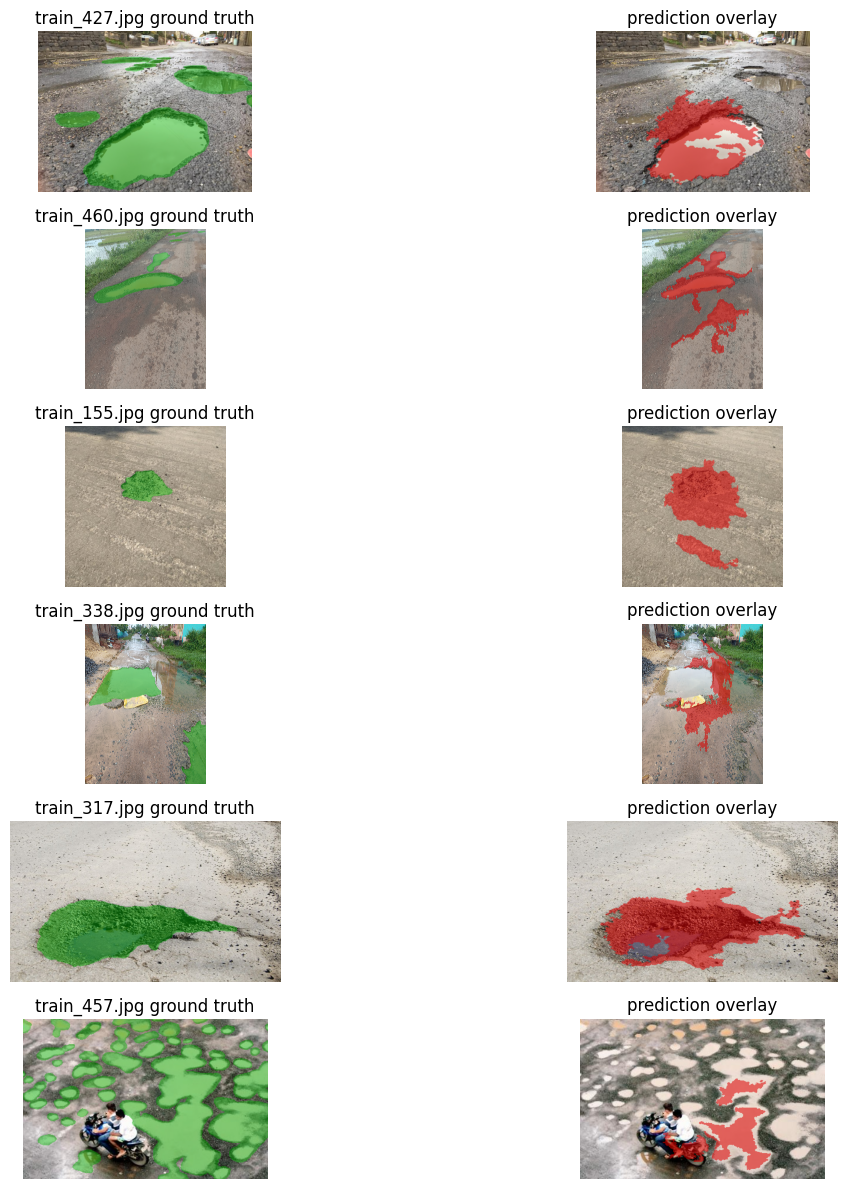

In [19]:
# ============================================================
# 12. Visual validation preview
# ============================================================

def overlay_mask(bgr, mask, color=(0, 0, 220), alpha=0.55):
    out = bgr.copy()
    color_img = np.zeros_like(bgr)
    color_img[:] = color
    px = mask > 0
    out[px] = (alpha * color_img[px] + (1 - alpha) * bgr[px]).astype(np.uint8)
    return out

n_show = min(6, len(val_items))
plt.figure(figsize=(14, 12))
for i in range(n_show):
    row = val_df.iloc[i]
    bgr = read_bgr(row["image_path"])
    prob = val_items[i]["prob"]
    pred_small = postprocess_probability(prob, best_post_cfg)
    pred = cv2.resize(pred_small, (bgr.shape[1], bgr.shape[0]), interpolation=cv2.INTER_NEAREST)
    gt = read_mask(row["mask_path"])
    gt_overlay = overlay_mask(bgr, gt, color=(0, 180, 0), alpha=0.45)
    pred_overlay = overlay_mask(bgr, pred, color=(0, 0, 220), alpha=0.55)

    plt.subplot(n_show, 2, 2*i + 1)
    plt.imshow(cv2.cvtColor(gt_overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{row['image_name']} ground truth")
    plt.axis("off")

    plt.subplot(n_show, 2, 2*i + 2)
    plt.imshow(cv2.cvtColor(pred_overlay, cv2.COLOR_BGR2RGB))
    plt.title("prediction overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 13. Test prediction and Kaggle submission CSV
# ============================================================

def rle_encode(mask):
    mask = (mask > 0).astype(np.uint8)
    pixels = mask.flatten(order=RLE_ORDER)
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)


def predict_test_mask_original_size(image_path, model, cfg):
    bgr = read_bgr(image_path)
    prob = predict_probability_map(bgr, model, WORK_SIZE)
    mask_small = postprocess_probability(prob, cfg)
    mask = cv2.resize(mask_small, (bgr.shape[1], bgr.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask.astype(np.uint8)

submission_rows = []
t0 = time.time()
for i, (_, row) in enumerate(test_df.iterrows(), 1):
    mask = predict_test_mask_original_size(row["image_path"], EVAL_MODEL, best_post_cfg)
    submission_rows.append({"ImageId": row["ImageId"], "rle": rle_encode(mask)})
    if i % 25 == 0 or i == len(test_df):
        print(f"test: predicted {i}/{len(test_df)} images", flush=True)

submission = pd.DataFrame(submission_rows)
submission.to_csv("/kaggle/working/submission.csv" if Path("/kaggle/working").exists() else "submission.csv", index=False)
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
print("Saved submission.csv")
print("Test prediction time:", round(time.time() - t0, 1), "seconds")
display(submission.head())


test: predicted 25/295 images
test: predicted 50/295 images
test: predicted 75/295 images
test: predicted 100/295 images
test: predicted 125/295 images
test: predicted 150/295 images
test: predicted 175/295 images
test: predicted 200/295 images
test: predicted 225/295 images
test: predicted 250/295 images
test: predicted 275/295 images
test: predicted 295/295 images
Saved submission.csv
Test prediction time: 1624.7 seconds


,ImageId,rle
0,test_001.jpg,27720 3 28020 3 28320 5 28620 6 28920 6 29220 ...
1,test_002.jpg,151586 5 152306 5 153024 9 153744 9 154464 7 1...
2,test_003.jpg,2139120 7 2141416 7 2143712 7 2146008 7 214830...
3,test_004.jpg,53915 1 54214 3 54514 3 54814 4 55114 4 55415 ...
4,test_005.jpg,36193 1 36493 1 36792 3 36796 1 37091 7 37390 ...


In [21]:
# ============================================================
# 14. Save deployment artifacts
# ============================================================

# Save fast model for Streamlit real-time mode.
joblib.dump(fast_model, OUTPUT_DIR / "pothole_model_fast.pkl")

# Save accuracy model for report and optional app accuracy mode.
joblib.dump(accuracy_model, OUTPUT_DIR / "pothole_model_accuracy.pkl")
joblib.dump(accuracy_model, OUTPUT_DIR / "pothole_model.pkl")

if "lgbm" in trained_models and hasattr(trained_models["lgbm"], "feature_importances_"):
    fi = pd.DataFrame({"feature": FEATURE_NAMES, "importance": trained_models["lgbm"].feature_importances_})
    fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)
    fi.to_csv(OUTPUT_DIR / "feature_importance_lgbm.csv", index=False)
    display(fi.head(20))

config = {
    "work_size": WORK_SIZE,
    "app_work_size": APP_WORK_SIZE,
    "feature_names": FEATURE_NAMES,
    "best_postprocess": best_post_cfg,
    "validation_metrics": val_metrics,
    "train_subset_metrics": train_metrics,
    "fast_model": "pothole_model_fast.pkl",
    "accuracy_model": "pothole_model_accuracy.pkl",
    "main_model": "pothole_model.pkl",
    "model_note": "ARA 7.0 segmentation with RDD2022 India negative only hard negatives. Classical ML only.",
    "external_data": {
        "rdd_india_used": bool(len(rdd_df) > 0 and len(y_rdd) > 0),
        "rdd_images_used_max": int(MAX_RDD_IMAGES),
        "rdd_negative_pixels": int(len(y_rdd)),
    },
}

with open(OUTPUT_DIR / "pothole_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts to:", OUTPUT_DIR)
print(sorted([p.name for p in OUTPUT_DIR.iterdir()]))


,feature,importance
0,y_norm,9732
1,illum_norm,5097
2,blackhat61,4818
3,wet_like,4186
4,x_norm,4148
5,mean15,3864
6,clahe,3606
7,std15,3544
8,shadow_like,3528
9,HSV_H,3521


Saved artifacts to: /kaggle/working/pothole_output
['dataset_audit.csv', 'feature_importance_lgbm.csv', 'pothole_config.json', 'pothole_model.pkl', 'pothole_model_accuracy.pkl', 'pothole_model_fast.pkl', 'sample_model_comparison.csv', 'submission.csv', 'threshold_search.csv', 'train_items_30.pkl', 'train_val_metrics.csv', 'val_items_accuracy.pkl', 'validation_metrics.csv']


In [22]:
# ============================================================
# 15. Write Streamlit app.py and requirements.txt
# ============================================================

from pathlib import Path

app_code = '\nfrom __future__ import annotations\n\nimport json\nimport time\nimport warnings\nfrom pathlib import Path\n\nimport cv2\nimport joblib\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\nfrom PIL import Image, ImageOps, UnidentifiedImageError\nfrom skimage.feature import local_binary_pattern\n\nwarnings.filterwarnings("ignore")\n\nAPP_DIR = Path(__file__).resolve().parent\n\n\ndef find_artifact_dir() -> Path:\n    candidates = [\n        APP_DIR / "pothole_output",\n        APP_DIR,\n        APP_DIR.parent / "pothole_output",\n        Path.cwd() / "pothole_output",\n        Path.cwd(),\n    ]\n    for folder in candidates:\n        if (folder / "pothole_config.json").exists() and (\n            (folder / "pothole_model_fast.pkl").exists()\n            or (folder / "pothole_model.pkl").exists()\n            or (folder / "pothole_model_accuracy.pkl").exists()\n        ):\n            return folder\n    raise FileNotFoundError(\n        "Artifact model tidak ditemukan. Pastikan pothole_config.json dan file model pkl ada di folder pothole_output."\n    )\n\n\nARTIFACT_DIR = find_artifact_dir()\nCONFIG_PATH = ARTIFACT_DIR / "pothole_config.json"\n\nwith open(CONFIG_PATH, "r") as f:\n    CFG = json.load(f)\n\nFEATURE_NAMES = CFG["feature_names"]\nDEFAULT_WORK_SIZE = int(CFG.get("app_work_size", CFG.get("work_size", 256)))\nDEFAULT_THRESHOLD = float(CFG.get("best_postprocess", {}).get("threshold", 0.60))\nDEFAULT_MIN_AREA = int(CFG.get("best_postprocess", {}).get("min_area", 250))\nDEFAULT_CLOSE_K = int(CFG.get("best_postprocess", {}).get("close_k", 5))\nDEFAULT_OPEN_K = int(CFG.get("best_postprocess", {}).get("open_k", 3))\nDEFAULT_FILL = bool(CFG.get("best_postprocess", {}).get("fill", False))\nDEFAULT_MAX_AREA_RATIO = float(CFG.get("best_postprocess", {}).get("max_area_ratio", 0.22))\nMODEL_NOTE = CFG.get("model_note", "Classical machine learning pothole segmentation")\n\n\nclass SoftProbabilityEnsemble:\n    def __init__(self, models, model_names=None, weights=None):\n        self.models = models\n        self.model_names = model_names if model_names is not None else [f"model_{i}" for i in range(len(models))]\n        self.weights = None if weights is None else np.asarray(weights, dtype=np.float32)\n        self.classes_ = np.array([0, 1], dtype=int)\n\n    def _positive_proba(self, model, X):\n        raw = np.asarray(model.predict_proba(X), dtype=np.float32)\n        if raw.ndim == 1:\n            return raw\n        if hasattr(model, "classes_"):\n            classes = np.asarray(model.classes_).astype(int)\n            if 1 in classes:\n                pos_idx = int(np.where(classes == 1)[0][0])\n                return raw[:, pos_idx]\n        if raw.shape[1] == 2:\n            return raw[:, 1]\n        return raw[:, -1]\n\n    def predict_proba(self, X):\n        probs = []\n        weights = []\n        for i, model in enumerate(self.models):\n            if not hasattr(model, "predict_proba"):\n                continue\n            probs.append(self._positive_proba(model, X))\n            weights.append(1.0 if self.weights is None else float(self.weights[i]))\n        if not probs:\n            raise RuntimeError("Tidak ada model predict_proba valid di ensemble.")\n        W = np.asarray(weights, dtype=np.float32)\n        W = W / (W.sum() + 1e-8)\n        p1 = np.zeros_like(probs[0], dtype=np.float32)\n        for p, w in zip(probs, W):\n            p1 += w * p.astype(np.float32)\n        p1 = np.clip(p1, 0, 1)\n        return np.vstack([1 - p1, p1]).T\n\n    def predict(self, X):\n        return (self.predict_proba(X)[:, 1] >= 0.5).astype(np.uint8)\n\n\n@st.cache_resource\ndef load_models():\n    fast_path = ARTIFACT_DIR / "pothole_model_fast.pkl"\n    acc_path = ARTIFACT_DIR / "pothole_model_accuracy.pkl"\n    main_path = ARTIFACT_DIR / "pothole_model.pkl"\n\n    fast_model = None\n    acc_model = None\n\n    if fast_path.exists():\n        fast_model = joblib.load(fast_path)\n    elif main_path.exists():\n        fast_model = joblib.load(main_path)\n\n    if acc_path.exists():\n        acc_model = joblib.load(acc_path)\n    elif main_path.exists():\n        acc_model = joblib.load(main_path)\n    elif fast_model is not None:\n        acc_model = fast_model\n\n    if fast_model is None and acc_model is None:\n        raise FileNotFoundError("Tidak ada file model pkl di artifact directory.")\n\n    return fast_model, acc_model\n\n\ndef read_uploaded_image(uploaded_file):\n    data = uploaded_file.getvalue()\n    try:\n        pil = Image.open(__import__("io").BytesIO(data))\n        pil = ImageOps.exif_transpose(pil)\n        if pil.mode in ("RGBA", "LA"):\n            bg = Image.new("RGB", pil.size, (255, 255, 255))\n            bg.paste(pil, mask=pil.split()[-1])\n            pil = bg\n        else:\n            pil = pil.convert("RGB")\n        rgb = np.array(pil)\n        return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)\n    except (UnidentifiedImageError, Exception):\n        arr = np.frombuffer(data, dtype=np.uint8)\n        bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)\n        return bgr\n\n\ndef normalize01(x):\n    x = x.astype(np.float32)\n    mn = float(np.nanmin(x))\n    mx = float(np.nanmax(x))\n    if mx - mn < 1e-8:\n        return np.zeros_like(x, dtype=np.float32)\n    return ((x - mn) / (mx - mn + 1e-8)).astype(np.float32)\n\n\ndef local_mean_std(gray, k=7):\n    gray = gray.astype(np.float32)\n    mean = cv2.blur(gray, (k, k))\n    mean_sq = cv2.blur(gray * gray, (k, k))\n    var = np.maximum(mean_sq - mean * mean, 0)\n    std = np.sqrt(var)\n    return mean.astype(np.float32), normalize01(std)\n\n\ndef conservative_road_mask(bgr):\n    h, w = bgr.shape[:2]\n    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)\n    H, S, V = cv2.split(hsv)\n\n    sky = np.zeros((h, w), dtype=np.uint8)\n    top_h = max(1, h // 2)\n    sky_region = ((H[:top_h] >= 85) & (H[:top_h] <= 140) & (S[:top_h] <= 135) & (V[:top_h] >= 80))\n    sky[:top_h][sky_region] = 1\n\n    g = bgr[:, :, 1].astype(np.int16)\n    r = bgr[:, :, 2].astype(np.int16)\n    veg = ((H >= 25) & (H <= 95) & (S >= 35) & (g > r + 5)).astype(np.uint8)\n\n    road = (1 - np.clip(sky + veg, 0, 1)).astype(np.uint8)\n    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))\n    road = cv2.morphologyEx(road * 255, cv2.MORPH_CLOSE, k, iterations=2)\n    road = cv2.morphologyEx(road, cv2.MORPH_OPEN, k, iterations=1)\n    road = (road > 0).astype(np.uint8)\n\n    n, labels, stats, cent = cv2.connectedComponentsWithStats(road, 8)\n    if n <= 1:\n        fallback = np.zeros((h, w), dtype=np.uint8)\n        fallback[h // 3:] = 1\n        return fallback\n\n    best = 1\n    best_score = -1\n    for lab in range(1, n):\n        area = stats[lab, cv2.CC_STAT_AREA]\n        cy = cent[lab][1]\n        score = area * (0.4 + cy / max(h, 1))\n        if score > best_score:\n            best_score = score\n            best = lab\n    road = (labels == best).astype(np.uint8)\n    road[: int(h * 0.06)] = 0\n    return road\n\n\ndef build_gabor_kernels():\n    kernels = []\n    for theta in [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]:\n        kernels.append(cv2.getGaborKernel((15, 15), 3.0, theta, 8.0, 0.5, 0, ktype=cv2.CV_32F))\n    return kernels\n\n\nGABOR_KERNELS = build_gabor_kernels()\n\n\ndef build_feature_map(bgr):\n    h, w = bgr.shape[:2]\n    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0\n    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)\n    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)\n\n    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0\n    gray_u8 = (gray * 255).astype(np.uint8)\n    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray_u8).astype(np.float32) / 255.0\n    illum = cv2.GaussianBlur(gray, (0, 0), sigmaX=25)\n    illum_norm = normalize01(gray / (illum + 1e-4))\n\n    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)\n    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)\n    grad_mag = normalize01(np.sqrt(sx * sx + sy * sy))\n    grad_ang = (np.arctan2(sy, sx) + np.pi) / (2 * np.pi)\n    lap = normalize01(np.abs(cv2.Laplacian(gray, cv2.CV_32F, ksize=3)))\n\n    mean7, std7 = local_mean_std(gray, 7)\n    mean15, std15 = local_mean_std(gray, 15)\n\n    blackhat_feats = []\n    for ksize in [15, 31, 61]:\n        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))\n        bh = cv2.morphologyEx(gray_u8, cv2.MORPH_BLACKHAT, kernel).astype(np.float32)\n        blackhat_feats.append(normalize01(bh))\n\n    lbp = local_binary_pattern(gray_u8, P=8, R=1, method="uniform").astype(np.float32)\n    lbp = lbp / (lbp.max() + 1e-8)\n\n    gabor_feats = []\n    for kern in GABOR_KERNELS:\n        resp = cv2.filter2D(gray, cv2.CV_32F, kern)\n        gabor_feats.append(normalize01(np.abs(resp)))\n\n    ys, xs = np.mgrid[0:h, 0:w]\n    x_norm = xs.astype(np.float32) / max(w - 1, 1)\n    y_norm = ys.astype(np.float32) / max(h - 1, 1)\n    bottom_prior = y_norm ** 2\n    center_x = np.abs(x_norm - 0.5)\n\n    road = conservative_road_mask(bgr).astype(np.float32)\n\n    H = hsv[:, :, 0] / 179.0\n    S = hsv[:, :, 1] / 255.0\n    V = hsv[:, :, 2] / 255.0\n    L = lab[:, :, 0] / 255.0\n    A = lab[:, :, 1] / 255.0\n    B = lab[:, :, 2] / 255.0\n\n    # Water and shadow related features. They help reduce false positives from wet road and reflection.\n    low_sat = 1.0 - S\n    dark = 1.0 - V\n    wet_like = normalize01(low_sat * (0.5 * V + 0.5 * (1.0 - std15)))\n    shadow_like = normalize01(dark * low_sat * (1.0 - grad_mag))\n    dark_edge = normalize01(dark * grad_mag)\n    specular_like = normalize01((V > 0.75).astype(np.float32) * low_sat * (1.0 - S))\n\n    maps = [\n        rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2],\n        H, S, V,\n        L, A, B,\n        gray, clahe, illum_norm,\n        grad_mag, grad_ang, lap,\n        mean7, std7, mean15, std15,\n        lbp,\n        x_norm, y_norm, bottom_prior, center_x,\n        road,\n        wet_like, shadow_like, dark_edge, specular_like,\n    ]\n    maps.extend(blackhat_feats)\n    maps.extend(gabor_feats)\n    feat = np.stack(maps, axis=-1).astype(np.float32)\n\n    if feat.shape[-1] != len(FEATURE_NAMES):\n        raise RuntimeError(f"Feature mismatch. App has {feat.shape[-1]} features but config expects {len(FEATURE_NAMES)}.")\n    return feat\n\n\ndef positive_proba(model, X, batch_size=120000):\n    out = np.zeros(X.shape[0], dtype=np.float32)\n    for start in range(0, X.shape[0], batch_size):\n        end = min(start + batch_size, X.shape[0])\n        raw = np.asarray(model.predict_proba(X[start:end]), dtype=np.float32)\n        if raw.ndim == 1:\n            out[start:end] = raw\n        elif hasattr(model, "classes_") and 1 in np.asarray(model.classes_).astype(int):\n            idx = int(np.where(np.asarray(model.classes_).astype(int) == 1)[0][0])\n            out[start:end] = raw[:, idx]\n        else:\n            out[start:end] = raw[:, -1]\n    return out\n\n\ndef predict_probability_map(bgr, model, work_size):\n    bgr_r = cv2.resize(bgr, (work_size, work_size), interpolation=cv2.INTER_AREA)\n    feat = build_feature_map(bgr_r)\n    X = feat.reshape(-1, feat.shape[-1]).astype(np.float32)\n\n    t_model = time.perf_counter()\n    prob = positive_proba(model, X).reshape(work_size, work_size)\n    model_ms = (time.perf_counter() - t_model) * 1000\n\n    road = feat[:, :, FEATURE_NAMES.index("road_mask")]\n    prob = prob * (road > 0.5)\n    return prob.astype(np.float32), model_ms\n\n\ndef remove_small_components(mask, min_area=250, keep_largest=False):\n    mask_u8 = (mask > 0).astype(np.uint8)\n    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, 8)\n    out = np.zeros_like(mask_u8)\n    comps = []\n    for lab in range(1, n):\n        area = int(stats[lab, cv2.CC_STAT_AREA])\n        if area >= min_area:\n            comps.append((area, lab))\n    if keep_largest and comps:\n        comps = [max(comps, key=lambda x: x[0])]\n    for _, lab in comps:\n        out[labels == lab] = 1\n    return out\n\n\ndef fill_holes(mask):\n    mask_u8 = (mask > 0).astype(np.uint8)\n    h, w = mask_u8.shape\n    flood = (mask_u8 * 255).astype(np.uint8)\n    temp = flood.copy()\n    ff = np.zeros((h + 2, w + 2), np.uint8)\n    cv2.floodFill(temp, ff, (0, 0), 255)\n    inv = cv2.bitwise_not(temp)\n    filled = cv2.bitwise_or(flood, inv)\n    return (filled > 0).astype(np.uint8)\n\n\ndef postprocess_probability(prob, threshold, min_area, close_k, open_k, fill, max_area_ratio=0.22, keep_largest=False):\n    threshold = float(threshold)\n\n    # Area control. If predicted area is unrealistically large, increase threshold automatically.\n    chosen_th = threshold\n    while chosen_th <= 0.93:\n        mask = (prob >= chosen_th).astype(np.uint8)\n        if mask.mean() <= max_area_ratio:\n            break\n        chosen_th += 0.04\n\n    mask = (prob >= chosen_th).astype(np.uint8)\n\n    if close_k and close_k > 1:\n        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(close_k), int(close_k)))\n        mask = cv2.morphologyEx(mask * 255, cv2.MORPH_CLOSE, k, iterations=1)\n        mask = (mask > 0).astype(np.uint8)\n\n    if open_k and open_k > 1:\n        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(open_k), int(open_k)))\n        mask = cv2.morphologyEx(mask * 255, cv2.MORPH_OPEN, k, iterations=1)\n        mask = (mask > 0).astype(np.uint8)\n\n    if fill:\n        mask = fill_holes(mask)\n\n    mask = remove_small_components(mask, min_area=int(min_area), keep_largest=keep_largest)\n    return mask.astype(np.uint8), chosen_th\n\n\ndef make_overlay(bgr, mask, color_bgr=(0, 0, 220), alpha=0.55):\n    out = bgr.copy()\n    color = np.zeros_like(bgr)\n    color[:] = color_bgr\n    px = mask > 0\n    out[px] = (alpha * color[px] + (1 - alpha) * bgr[px]).astype(np.uint8)\n    return out\n\n\ndef bgr_to_rgb(bgr):\n    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)\n\n\ndef compute_binary_metrics(pred, gt):\n    pred = (pred > 0).astype(np.uint8)\n    gt = (gt > 127).astype(np.uint8) if gt.max() > 1 else (gt > 0).astype(np.uint8)\n    if pred.shape != gt.shape:\n        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)\n    tp = float(((pred == 1) & (gt == 1)).sum())\n    tn = float(((pred == 0) & (gt == 0)).sum())\n    fp = float(((pred == 1) & (gt == 0)).sum())\n    fn = float(((pred == 0) & (gt == 1)).sum())\n    eps = 1e-8\n    iou_fg = tp / (tp + fp + fn + eps)\n    iou_bg = tn / (tn + fp + fn + eps)\n    dice = 2 * tp / (2 * tp + fp + fn + eps)\n    precision = tp / (tp + fp + eps)\n    recall = tp / (tp + fn + eps)\n    pixel_acc = (tp + tn) / (tp + tn + fp + fn + eps)\n    f1_bg = 2 * tn / (2 * tn + fp + fn + eps)\n    return {\n        "IoU Pothole": iou_fg,\n        "mIoU": (iou_fg + iou_bg) / 2,\n        "Dice": dice,\n        "Pixel Accuracy": pixel_acc,\n        "Precision": precision,\n        "Recall": recall,\n        "Macro F1": (dice + f1_bg) / 2,\n    }\n\n\ndef main():\n    st.set_page_config(page_title="Pothole Detection", layout="wide")\n\n    st.title("Pothole Detection")\n    st.caption("Classical machine learning segmentation with ARA 7.0 and RDD2022 India hard negatives")\n\n    try:\n        fast_model, acc_model = load_models()\n    except Exception as e:\n        st.error(str(e))\n        st.stop()\n\n    with st.sidebar:\n        st.header("Model settings")\n        mode = st.radio("Inference mode", ["Real-time", "Accuracy"], index=0)\n        work_size = st.selectbox("Processing size", [224, 256, 320, 384], index=[224, 256, 320, 384].index(DEFAULT_WORK_SIZE) if DEFAULT_WORK_SIZE in [224,256,320,384] else 1)\n        st.caption("Use 256 for faster demo. Use 320 or 384 for cleaner masks.")\n\n        st.subheader("Post-processing")\n        threshold = st.slider("Probability threshold", 0.30, 0.95, DEFAULT_THRESHOLD, 0.01)\n        min_area = st.slider("Minimum area", 50, 3000, DEFAULT_MIN_AREA, 50)\n        close_k = st.select_slider("Close kernel", options=[0, 3, 5, 7, 9, 11], value=DEFAULT_CLOSE_K if DEFAULT_CLOSE_K in [0,3,5,7,9,11] else 5)\n        open_k = st.select_slider("Open kernel", options=[0, 3, 5, 7], value=DEFAULT_OPEN_K if DEFAULT_OPEN_K in [0,3,5,7] else 3)\n        fill = st.checkbox("Fill holes", value=DEFAULT_FILL)\n        max_area_ratio = st.slider("Max predicted area ratio", 0.03, 0.60, DEFAULT_MAX_AREA_RATIO, 0.01)\n        keep_largest = st.checkbox("Keep largest component only", value=False)\n\n        st.subheader("Artifact")\n        st.write(f"Folder: `{ARTIFACT_DIR}`")\n        st.write(MODEL_NOTE)\n\n    uploaded = st.file_uploader("Upload road image", type=["jpg", "jpeg", "png", "bmp", "webp", "tif", "tiff"])\n\n    if uploaded is None:\n        st.info("Upload a road image to start detection.")\n        st.stop()\n\n    bgr = read_uploaded_image(uploaded)\n    if bgr is None:\n        st.error("Image cannot be read.")\n        st.stop()\n\n    model = fast_model if mode == "Real-time" else acc_model\n\n    with st.spinner("Running detection..."):\n        t_total = time.perf_counter()\n        prob, model_ms = predict_probability_map(bgr, model, int(work_size))\n        mask_small, used_th = postprocess_probability(\n            prob,\n            threshold=threshold,\n            min_area=min_area,\n            close_k=close_k,\n            open_k=open_k,\n            fill=fill,\n            max_area_ratio=max_area_ratio,\n            keep_largest=keep_largest,\n        )\n        mask = cv2.resize(mask_small, (bgr.shape[1], bgr.shape[0]), interpolation=cv2.INTER_NEAREST)\n        total_ms = (time.perf_counter() - t_total) * 1000\n\n    overlay = make_overlay(bgr, mask)\n    prob_vis = (np.clip(prob, 0, 1) * 255).astype(np.uint8)\n    prob_vis = cv2.applyColorMap(prob_vis, cv2.COLORMAP_JET)\n\n    area_pct = float((mask > 0).mean() * 100)\n\n    m1, m2, m3, m4 = st.columns(4)\n    m1.metric("Detected area", f"{area_pct:.2f}%")\n    m2.metric("Total time", f"{total_ms:.1f} ms")\n    m3.metric("Model time", f"{model_ms:.1f} ms")\n    m4.metric("Used threshold", f"{used_th:.2f}")\n\n    c1, c2, c3 = st.columns(3)\n    with c1:\n        st.subheader("Original")\n        st.image(bgr_to_rgb(bgr), use_container_width=True)\n    with c2:\n        st.subheader("Predicted mask")\n        st.image(mask * 255, clamp=True, use_container_width=True)\n    with c3:\n        st.subheader("Overlay")\n        st.image(bgr_to_rgb(overlay), use_container_width=True)\n\n    with st.expander("Probability heatmap"):\n        st.image(bgr_to_rgb(prob_vis), use_container_width=True)\n\n    ok, buf = cv2.imencode(".png", mask * 255)\n    if ok:\n        st.download_button("Download predicted mask", data=buf.tobytes(), file_name="predicted_mask.png", mime="image/png")\n\n    st.divider()\n    st.subheader("Optional evaluation")\n    gt_file = st.file_uploader("Upload ground truth mask for this image", type=["png", "jpg", "jpeg"], key="gt")\n    if gt_file is not None:\n        gt_data = np.frombuffer(gt_file.getvalue(), dtype=np.uint8)\n        gt = cv2.imdecode(gt_data, cv2.IMREAD_GRAYSCALE)\n        if gt is not None:\n            metrics = compute_binary_metrics(mask, gt)\n            df = pd.DataFrame([metrics]).T.reset_index()\n            df.columns = ["Metric", "Value"]\n            df["Value"] = df["Value"].map(lambda x: f"{x:.4f}")\n            st.dataframe(df, use_container_width=True)\n        else:\n            st.warning("Ground truth mask cannot be read.")\n\n\nif __name__ == "__main__":\n    main()\n'
requirements_text = 'opencv-python-headless>=4.8.0\nnumpy>=1.24.0\npandas>=2.0.0\nscikit-learn>=1.3.0\nscikit-image>=0.21.0\nmatplotlib>=3.7.0\njoblib>=1.3.0\nstreamlit>=1.28.0\nPillow>=10.0.0\nlightgbm>=4.0.0\nxgboost>=2.0.0\ncatboost>=1.2.0\n'

app_path = Path("/kaggle/working/app.py") if Path("/kaggle/working").exists() else Path("app.py")
req_path = Path("/kaggle/working/requirements.txt") if Path("/kaggle/working").exists() else Path("requirements.txt")

app_path.write_text(app_code, encoding="utf-8")
req_path.write_text(requirements_text, encoding="utf-8")

print("Saved app:", app_path)
print("Saved requirements:", req_path)


Saved app: /kaggle/working/app.py
Saved requirements: /kaggle/working/requirements.txt


In [23]:
# ============================================================
# 16. Zip artifacts for download
# ============================================================

import shutil

zip_path = Path("/kaggle/working/pothole_artifacts.zip") if Path("/kaggle/working").exists() else Path("pothole_artifacts.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.glob("*"):
        if p.is_file():
            zf.write(p, arcname=f"pothole_output/{p.name}")
    app_path = Path("/kaggle/working/app.py") if Path("/kaggle/working").exists() else Path("app.py")
    req_path = Path("/kaggle/working/requirements.txt") if Path("/kaggle/working").exists() else Path("requirements.txt")
    if app_path.exists():
        zf.write(app_path, arcname="app.py")
    if req_path.exists():
        zf.write(req_path, arcname="requirements.txt")

print("Saved zip:", zip_path)
print("Done")


Saved zip: /kaggle/working/pothole_artifacts.zip
Done


## How to use the Streamlit app

After running the notebook, download `pothole_artifacts.zip`. Extract it locally with this structure:

```text
project/
  app.py
  requirements.txt
  pothole_output/
    pothole_model_fast.pkl
    pothole_model_accuracy.pkl
    pothole_model.pkl
    pothole_config.json
```

Run:

```bash
pip install -r requirements.txt
python -m streamlit run app.py
```

Use Real-time mode for demo speed. Use Accuracy mode when you want the cleaner ensemble output.


In [ ]:
# ============================================================
# 12B. Validation Testing Simulation
# ============================================================

def make_overlay_rgb(bgr, mask, color_bgr=(0, 0, 255), alpha=0.45):
    img = bgr.copy()
    color = np.zeros_like(img)
    color[:] = color_bgr
    px = mask > 0
    img[px] = (alpha * color[px] + (1 - alpha) * img[px]).astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def make_error_map_rgb(gt, pred):
    """
    Green = True Positive
    Red   = False Positive
    Blue  = False Negative
    Black = True Negative
    """
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    out = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.uint8)

    tp = (gt == 1) & (pred == 1)
    fp = (gt == 0) & (pred == 1)
    fn = (gt == 1) & (pred == 0)

    out[tp] = [0, 200, 0]
    out[fp] = [255, 0, 0]
    out[fn] = [0, 80, 255]

    return out


def classify_result(m):
    iou = m["iou_pothole"]
    dice = m["dice"]
    precision = m["precision"]
    recall = m["recall"]

    if iou >= 0.50 and dice >= 0.65:
        quality = "Good"
    elif iou >= 0.30 and dice >= 0.45:
        quality = "Acceptable"
    else:
        quality = "Weak"

    if precision < 0.45 and recall >= 0.55:
        issue = "Over-detection / false positive"
    elif recall < 0.45 and precision >= 0.45:
        issue = "Under-detection / missed pothole"
    elif precision < 0.45 and recall < 0.45:
        issue = "Unstable prediction"
    else:
        issue = "Balanced enough"

    return quality, issue


def build_validation_simulation_table(val_items, val_df, cfg):
    path_map = dict(zip(val_df["image_name"], val_df["image_path"]))
    rows = []

    for item in val_items:
        pred = postprocess_probability(item["prob"], cfg)
        gt = item["gt"]

        m = compute_binary_metrics(pred, gt)
        quality, issue = classify_result(m)

        rows.append({
            "image_name": item["image_name"],
            "quality": quality,
            "main_issue": issue,
            "iou_pothole": m["iou_pothole"],
            "dice": m["dice"],
            "precision": m["precision"],
            "recall": m["recall"],
            "miou": m["miou"],
            "pred_area_ratio": float((pred > 0).mean()),
            "gt_area_ratio": float((gt > 0).mean()),
            "image_path": path_map.get(item["image_name"], ""),
        })

    df_sim = pd.DataFrame(rows)
    return df_sim.sort_values(
        ["quality", "iou_pothole"],
        ascending=[True, False]
    ).reset_index(drop=True)


sim_df = build_validation_simulation_table(val_items, val_df, best_post_cfg)

print("Validation simulation summary")
print(sim_df["quality"].value_counts())
print()
print("Main issue summary")
print(sim_df["main_issue"].value_counts())

display(sim_df.sort_values("iou_pothole", ascending=False).head(10))
display(sim_df.sort_values("iou_pothole", ascending=True).head(10))

sim_df.to_csv(OUTPUT_DIR / "validation_testing_simulation.csv", index=False)
print("Saved:", OUTPUT_DIR / "validation_testing_simulation.csv")